# 3D Bulk - external field

This notebooks presents the simulation of a HTS bulk using H-formulation.

Short presentation of the test case with a nice figure to illustrate

In [119]:
# import packages from pyodide
import scipy
import matplotlib

____
## 1) Geometry and mesh

In [120]:
from utils.geometry import mesh_bulk_comsol
from ngsolve.webgui import Draw

mesh = mesh_bulk_comsol(eighth = True)
print(f"Imported 3D bulk mesh with {mesh.ne} tetrahedra, {mesh.nedge} edges and {mesh.nv} nodes.")
Draw(mesh)

Imported 3D bulk mesh with 5191 tetrahedra, 6565 edges and 1049 nodes.


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

_____
## 2) Physical parameters ######################################


### a) Default physical parameters

In [121]:
from ngsolve import pi

mu0 = 4e-7 * pi     # permeability of air (H/m)
rhoair = 1          # resistivity of air approximation (Ω·m)
epsJ = 2.2e-16      # tolerence to avoid the evaluation of zero at a negative power, used in the norm of current density ||J|| = sqrt(Jx^2+Jy^2+Jz^2+epsJ)

### b) Definition of the source field

In [122]:
Bmax = 0.5         # amplitude (T)
freq = 50           # frequency (Hz)

from ngsolve import cos, sin, CoefficientFunction as CF
H_s_dir = Bmax / mu0 * CF( (0, 0, 1))

Hs = lambda t : sin(2*pi*freq*t) * H_s_dir
derHs =  lambda t : 2 * pi * freq * cos(2*pi*freq*t) * H_s_dir 

### c) HTS resistivity model (power law)

In this notebook, the resistivity is defined by a power law as follows
$$\rho(\lVert \nabla \times H \rVert) =  \frac{E_c}{J_c} \left( \frac{ \lVert \nabla \times H \rVert}{J_c} \right)^{n-1} $$

with 
- $\rho$ the resistivity in $\Omega \cdot m$
- $H$ the magnetic field in $A\cdot m^{-1}$, so $\lVert \nabla \times H \lVert $ represents the norm of current density
- $E_c$ the critical electric field parameter in $V\cdot m^{-1}$
- $J_c$ the critical current density in $A\cdot m^{-2}$
- $n\gg1$ the resistivity exponent

In [123]:
n = 20 # 101            # n material parameter
Ec = 1e-4           # local critical current criterion (V/m)
Jc = 2.8e10         # critical current density (A/m²)

## HTS resistivity model
def rho_hts(normcurlH, Ec=Ec, Jc=Jc, n=n):
    """
    Resistivity of the superconductor defined by the power law : 
    rho(||curlH||) = (Ec/Jc)*(||curlH||/Jc)^(n-1)
    """
    return (Ec/Jc)*(normcurlH/Jc)**(n-1)

_____
## 3) Simulation 

### a) Time loop settings

We use adaptative time loop. When the convergence of the Newton algorithm of the physical solver fails, we reduce the time step; when it converges we increase the time step to accelerate the simulation.

In [ ]:
T_final = 1/freq    # final time = one period 
T_half = T_final/2  # half of the final time

dt_basic = T_final / 100
dt =  dt_basic / 2              # first time step
dt_min = dt_basic / 10000       # minimum time step
dt_max = dt_basic               # maximum time step

### b) H-formulation

The weak form of the residuals reads
$$ \mathcal R : 
\left \{
\begin{array}{lll}
H_0(\text{curl}, \Omega)^3 & \rightarrow & \mathbb{R} \\
\tilde{h}(t)\;,\; \tilde{h}_0(t)\;,\;v & \mapsto &
\displaystyle \int_\Omega \mu \partial_t (\tilde{h}(t) + h_s(t)) \cdot v \; \mathrm{d}x + \int_{\Omega} \hat{\rho}(\lVert \text{curl} \; \tilde{h}(t) \rVert ) \text{curl} \; \tilde{h}(t)  \cdot \text{curl} v \; \mathrm{d}x
\end{array}
\right. 
$$

with 
- $H_0(\text{curl}, \Omega) = \{h(t) \in H(\text{curl}, \Omega), h(t)|_{\Gamma_D} \times n = 0  \; \forall t\}$ the standard function space $H(\text{curl}, \Omega)$  with homogeneous Dirichlet condition on $\Gamma_D$. This function space should be discretized with appropriate edge-elements.
- $h_0(t) \in \{h(t) \in H(\text{curl}, \Omega), h(t)|_{\Gamma_D} \times n = H_0(t), \text{div}(h(t)) = 0 \; \forall t\}$ the source field, which is imposed and known for every $t$. Moreover $\text{curl}(h_0(t)) = 0,\;\forall t$ in the HTS
- $\hat{\rho}$ is the resistivity, which is $\rho(\lVert \text{curl} \; \tilde{h}(t) \rVert)$ in the HTS, and $\rho_0 \gg 1$ in the air. 

The time derivative is approximated with Cranck-Nicholson scheme. We aim to solve
$$\forall v \in H_0(\text{curl}, \Omega), \forall t \in [0, t_{max}],\quad \mathcal R(\tilde{h}(t), h_0(t), v) = 0 $$

In [125]:
## Function space
from ngsolve import HCurl
fes = HCurl(mesh, order=0, dirichlet="out|bottom.*")    # Functional space, order and boundary conditions
dH_tilde = fes.TrialFunction()                          # Unknown function (dofs)
v_test = fes.TestFunction()                             # Test function

## Initial field at t=0
from ngsolve import GridFunction
H_tilde_prev = GridFunction(fes)
## Residual from h-formulation
from ngsolve import curl, sqrt, dx


def residual(H_tilde, v, alpha = 0.5) :
    """
    Residual of H-formulation (alpha = 0.5 => Cranck-Nicolson, alpha = 0 => implicit Euler, alpha = 1 => explicit Euler)
    :param H_tilde: Trial function
    :param v: Test function
    :param time_stepping: Time stepping scheme
    """
    
    curls_H_tilde = alpha * curl(H_tilde_prev) + (1-alpha) * curl(H_tilde)
    normcurlH = sqrt(curls_H_tilde*curls_H_tilde + epsJ)
    curls_v = curl(v)

    res = mu0 * (1/dt_try) * H_tilde* v * dx
    res += -mu0 * (1/dt_try) * H_tilde_prev * v * dx
    res += rho_hts(normcurlH) * (curls_H_tilde) * (curls_v) * dx("hts")
    res += rhoair * (curls_H_tilde) * (curls_v) * dx("air")
    res += mu0 * derHs(t_next) * v * dx
    return res.Compile()

### c) Time loop

In [126]:
# Initialization

time_list = [0.0]           # list to store time instances
ac_losses_list = [0.0]      # list to store instantanuous AC losses 
steplist = []               # list to store time steps
Ed = 0.0                    # initial mean AC losses (W/m)

t_current = 0.0             # initial time
step = 0                    # time step counter

In [127]:
import time 
from utils.solver import newton
from ngsolve import Integrate

start = time.perf_counter()

while t_current < T_final:

    converged = False
    dt_try = dt  

    ## If we want to force to pass exactly at the moments T_final/2 and T_final
    if t_current < T_half < t_current + dt_try:
        dt_try = T_half - t_current
        print(f" Adjustment to reach T_final/2 : dt_try = {dt_try:.6e}")
    elif t_current + dt_try > T_final:
        dt_try = T_final - t_current
        print(f" Adjustment of the last step to reach T_final : dt_try = {dt_try:.6e}")

    while not converged:

        t_next = t_current + dt_try
        print(f"\n=== Step {step:4.0f} | ", end = '')
        print(f"Try: t={t_next:.6e}, dt={dt_try:.6e} | ", end = '')

        ### Initialisation solution for Newton-Raphson
        sol = GridFunction(fes)
        sol.vec.data = H_tilde_prev.vecs[-1]

        ### Nonlinear resolution with Newton-Raphson
        result = newton(fes = fes, 
                        residual = residual, 
                        initial_guess = sol, 
                        verbosity=1,
                        tol_res=1e-5,
                        tol_dec=1e-5,
                        rtol_res=1e-5
                        )

        ### Convergence check
        if result["status"] == 0 :
            converged = True
        else:
            new_dt_try = max(dt_try * 0.7, dt_min)  # time step reduction
            print(f"🔻 Newton failed, gradual reduction dt → {new_dt_try:.6e}")
            if new_dt_try == dt_min:
                raise RuntimeError("⛔ Impossible to converge even with minimal dt !")
            dt_try = new_dt_try
            continue

    ## Post-processing for this time step
    H_sol = result["solution"]
    H_t = H_sol + Hs(t_next)            # Global magnetic field
    J_hts = curl(H_sol)         # induced currents

    ### Instantaneous losses in the superconductor
    ac_losses = Integrate( J_hts * rho_hts(sqrt(J_hts*J_hts + epsJ)) * J_hts, mesh.Materials("hts"), order = 2)

    ### Integration of instantaneous losses per half cycle [T_half, T_final] : explicit Euler
    if t_next > T_half:
        if t_current < T_half:
            Ed += 2 * freq * ac_losses * (t_next - T_half)
        else:
            delta_t_eff = t_next - t_current    
            Ed += 2 * freq * ac_losses * (t_next - t_current)

    ### Store the results
    ac_losses_list.append(ac_losses)
    time_list.append(t_next)    
    steplist.append(dt_try)
    
    print(f"  ✔ Converged | Instant: {t_next:.6f} | Losses: {ac_losses:.6e}\r", end ='')

    ### Update for the next step 
    H_tilde_prev.Set(H_sol)
    t_current = t_next
    step += 1

    ### Adaptive adjustment: increase dt if everything is going well
    dt = min(dt_try * 2, dt_max)  

end = time.perf_counter()


=== Step    0 | Try: t=1.000000e-05, dt=1.000000e-05 |   ✔ Converged | Instant: 0.000010 | Losses: 1.371097e-68
=== Step    1 | Try: t=3.000000e-05, dt=2.000000e-05 |   ✔ Converged | Instant: 0.000030 | Losses: 1.438871e-58
=== Step    2 | Try: t=5.000000e-05, dt=2.000000e-05 |   ✔ Converged | Instant: 0.000050 | Losses: 6.549079e-54
=== Step    3 | Try: t=7.000000e-05, dt=2.000000e-05 |   ✔ Converged | Instant: 0.000070 | Losses: 7.669123e-51
=== Step    4 | Try: t=9.000000e-05, dt=2.000000e-05 |   ✔ Converged | Instant: 0.000090 | Losses: 1.499771e-48
=== Step    5 | Try: t=1.100000e-04, dt=2.000000e-05 |   ✔ Converged | Instant: 0.000110 | Losses: 1.013143e-46
=== Step    6 | Try: t=1.300000e-04, dt=2.000000e-05 |   ✔ Converged | Instant: 0.000130 | Losses: 3.375182e-45
=== Step    7 | Try: t=1.500000e-04, dt=2.000000e-05 |   ✔ Converged | Instant: 0.000150 | Losses: 6.801412e-44
=== Step    8 | Try: t=1.700000e-04, dt=2.000000e-05 |   ✔ Converged | Instant: 0.000170 | Losses: 9.39

KeyboardInterrupt: 

In [ ]:
Draw(H_t, mesh)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

_______
## 4) Final results

We finally display the results and compare with COMSOL computations.


Final results
Total simulation time : 63.503 s
Average losses Ed (half cycle) : 1.676853e-16 W/m


FileNotFoundError: results_COMSOL/2D/external_field/AC_Losses_500mT_quarter.txt not found.

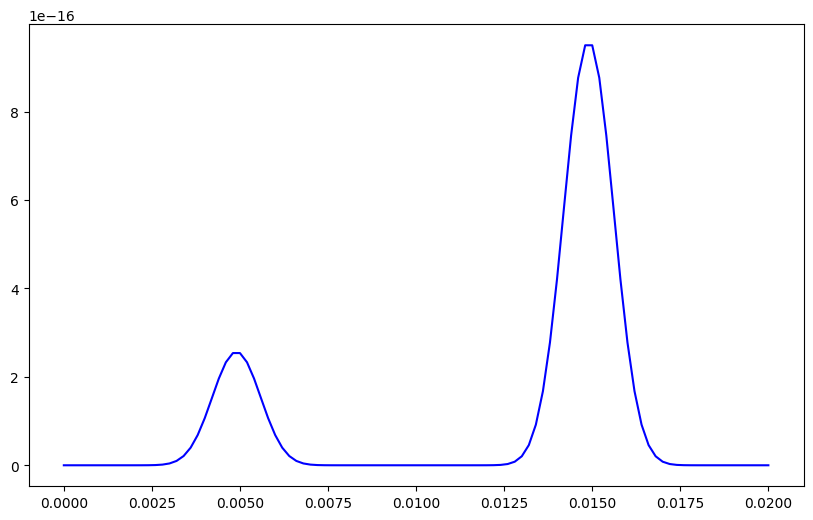

In [ ]:
print(f"\n{'='*50}")
print("Final results")
print(f"{'='*50}")
print(f"Total simulation time : {end-start:.3f} s")
print(f"Average losses Ed (half cycle) : {Ed:.6e} W/m")

## Data plot
from utils.trace import plot_result
plot_result(time_list, ac_losses_list, 
            filename_comsol = "results_COMSOL/2D/external_field/AC_Losses_"+str(int(Bmax*1000))+"mT_quarter.txt")